In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (14, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

from TB.utils import make_secondary_axis_plot 

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

In [3]:
tb = TimeseriesBuilder(
    irswaps_tb=IRSwapsTB(mdp=IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")),
    fixedratebonds_tb=FixedRateBondsTB(mdp=FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")),
)

In [4]:
start = datetime.date(2023, 1, 1)
end = datetime.date(2025, 10, 9)

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        # FixedRateBondQuery(cusip="CT5/CT30", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT2/CT5/CT10", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT3/CT5/CT10", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT2/CT5/CT7", value=FixedRateBondValue.YTM), 
        FixedRateBondQuery(cusip="CT3/CT5/CT7", value=FixedRateBondValue.YTM), 
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y/10Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT2/CT5/CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="2Y/10Y", value=IRSwapValue.RATE),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="oo2/oo10", value=IRSwapValue.RATE)
    ],
    n_jobs=8,
    # ignore_cache=True
)
df

PRICING FIXED-RATE BONDS.: 100%|██████████| 250/250 [06:34<00:00,  1.58s/it]


,FRB
,CT3/CT5/CT7 FLY YTM
Date,
2023-01-03,-20.276465
2023-01-04,-20.387383
2023-01-05,-21.099914
2023-01-06,-22.177378
2023-01-09,-20.741977
...,...
2025-10-03,-5.970064
2025-10-06,-7.083445


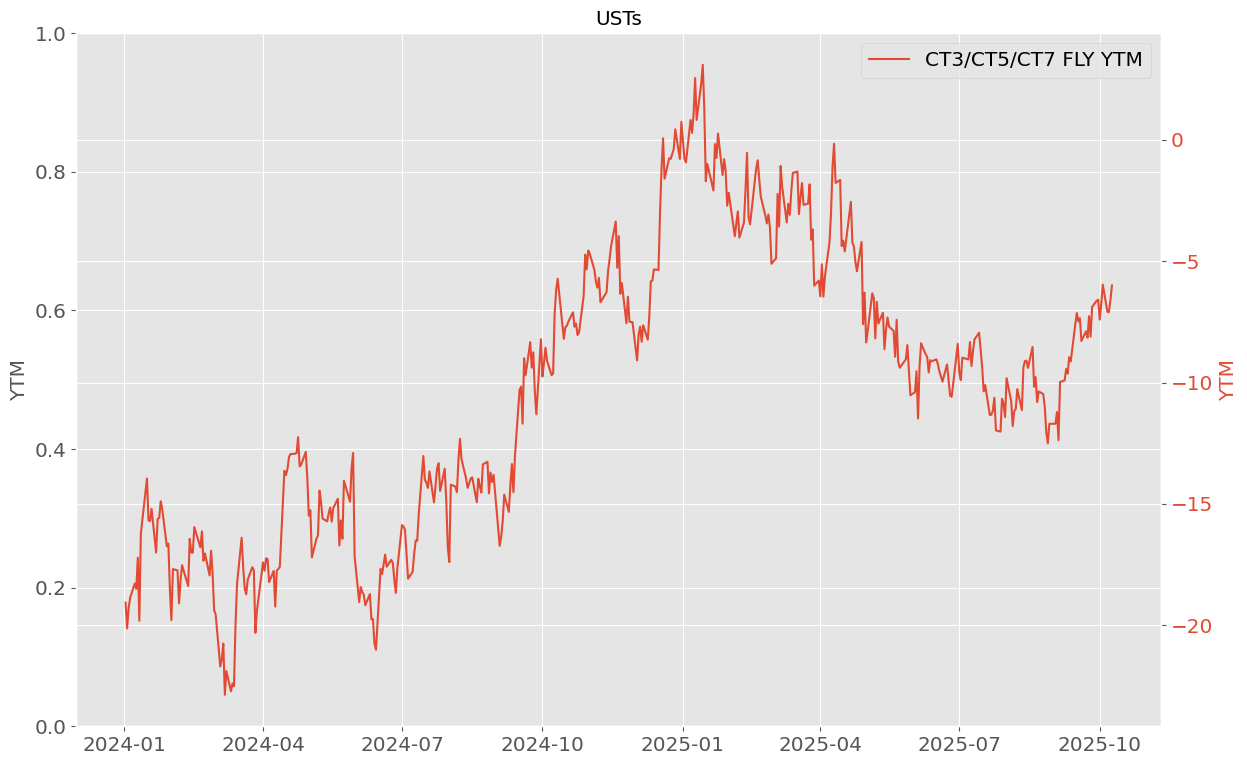

In [14]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left="YTM",
    ylabel_right="YTM",
    title="USTs"
)

# plot(df["FRB"]["CT10 OUTRIGHT YTM"], which="left")
# plot(df["FRB"]["CT2/CT5/CT10 FLY YTM"], which="left")
# plot(df["FRB"]["CT3/CT5/CT10 FLY YTM"], which="left")
# plot(df["FRB"]["CT2/CT5/CT7 FLY YTM"], which="right")
plot(df["FRB"]["CT3/CT5/CT7 FLY YTM"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT10 OUTRIGHT MMSS"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT2/CT5/CT10 FLY MMSS"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5/CT10 CURVE MMSS"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 5Y/10Y CURVE SPREADOVER"], which="right")

legend()
plt.show()




# plt.plot(df.index, df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"])